In [61]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import requests
import os

print("yfinance version: ",yf.__version__)
print("pandas version: ",pd.__version__)

print("numpy version: ", np.__version__)

yfinance version:  1.0
pandas version:  2.3.3
numpy version:  2.2.6


In [62]:
save_file = "sp500-data.csv"

if not os.path.exists(save_file):
    # Use requests (which handles SSL better) to fetch the page
    url = "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies"
    response = requests.get(url, headers={"User-Agent": "Mozilla/5.0"}, verify=False)

    # Parse the HTML from the response text
    sp500 = pd.read_html(response.text)[0]

    sp500['Symbol'] = sp500['Symbol'].str.replace('.', '-')

    symbols_list = sp500['Symbol'].unique().tolist()

    end_date = '2025-12-01'

    start_date = pd.to_datetime(end_date) - pd.DateOffset(365*10)

    df = yf.download(symbols_list,
                    start = start_date,
                    end = end_date,
                    auto_adjust=False)
    
    df = df.stack()

    df.to_csv(save_file)

df = pd.read_csv(save_file)
df

,Date,Ticker,Adj Close,Close,High,Low,Open,Volume
0,2015-12-04,A,37.911919,41.099998,41.209999,40.130001,40.230000,2519100.0
1,2015-12-04,AAPL,26.837566,29.757500,29.812500,28.777500,28.822500,231108000.0
2,2015-12-04,ABBV,37.727215,57.180000,57.480000,56.200001,56.500000,6748100.0
3,2015-12-04,ABT,37.522533,45.299999,45.360001,44.279999,44.410000,6438500.0
4,2015-12-04,ACGL,23.335051,24.540001,24.546667,24.136667,24.219999,990600.0
...,...,...,...,...,...,...,...,...
1225473,2025-11-28,XYZ,66.800003,66.800003,67.480003,65.500000,65.730003,3459900.0
1225474,2025-11-28,YUM,152.487885,153.210007,154.509995,153.059998,153.059998,923300.0
1225475,2025-11-28,ZBH,97.261467,97.519997,98.339996,97.300003,97.339996,890000.0
1225476,2025-11-28,ZBRA,252.750000,252.750000,254.970001,251.199997,251.949997,206400.0


In [63]:
# Create new S&P 500 summary dataframe
sp500_summary = df.groupby('Date').agg({
    'Adj Close': 'mean',
    'Close': 'mean',
    'High': 'mean',
    'Low': 'mean',
    'Open': 'mean',
    'Volume': 'sum'
}).reset_index()

# Rename columns for clarity
sp500_summary.columns = ['Date', 'Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume']

# Convert Date to datetime
sp500_summary['Date'] = pd.to_datetime(sp500_summary['Date'])

# Sort by date
sp500_summary = sp500_summary.sort_values('Date').reset_index(drop=True)

sp500_summary

,Date,Adj Close,Close,High,Low,Open,Volume
0,2015-12-04,64.071055,75.540824,75.875757,73.956305,74.298462,3.750601e+09
1,2015-12-07,63.681114,75.060835,75.821175,74.356025,75.358747,3.261978e+09
2,2015-12-08,63.426786,74.725300,75.403556,73.746853,74.481282,3.324575e+09
3,2015-12-09,62.721661,73.939559,75.394669,73.362184,74.436138,3.618925e+09
4,2015-12-10,62.892108,74.098413,74.847372,73.364598,73.982262,2.862508e+09
...,...,...,...,...,...,...,...
2506,2025-11-21,221.798150,222.156930,224.499594,216.775508,218.830044,4.058259e+09
2507,2025-11-24,222.823884,223.177521,225.664876,220.124503,222.382763,4.547867e+09
2508,2025-11-25,226.366386,226.718318,228.186648,221.974979,223.823613,3.336490e+09
2509,2025-11-26,227.548033,227.897834,229.864469,225.546554,226.859724,2.712272e+09


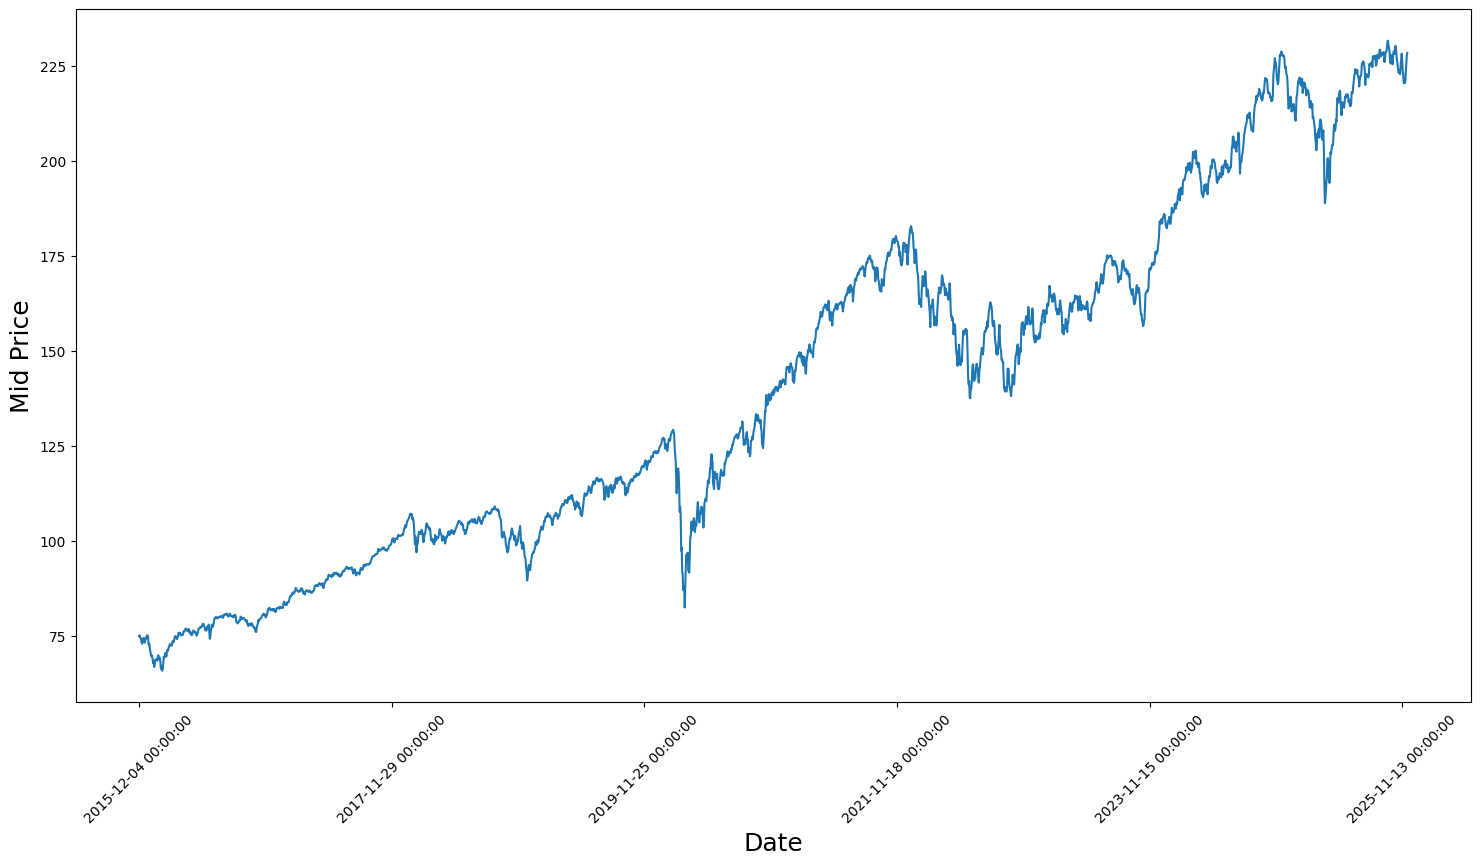

In [66]:
sp500_summary.head()

plt.figure(figsize=(18, 9))

# Fix: add parentheses for correct mid price calculation
plt.plot(range(sp500_summary.shape[0]), (sp500_summary['Low'] + sp500_summary['High']) / 2.0)

# Fix: use sp500_summary instead of df for xticks
plt.xticks(range(0, sp500_summary.shape[0], 500), sp500_summary['Date'].loc[::500], rotation=45)

plt.xlabel('Date', fontsize=18)
plt.ylabel('Mid Price', fontsize=18)
plt.show()